# Audio and Waveforms

## what is audio data?

Sound is vibrating air. A microphone measures air pressure deviation from rest:

- pushing outward → **positive value**
- pulling inward → **negative value**
- no movement → **zero (silence)**

This measurement is taken thousands of times per second and stored as a sequence of numbers — called a **waveform**.

| term | meaning |
|---|---|
| sample | one air pressure measurement at one point in time |
| sample rate (SR) | number of samples captured per second, in Hz |
| amplitude | the value of a sample — how loud the sound is at that moment |
| waveform | the full sequence of samples over time |
| duration | total length of audio in seconds |

## the nyquist theorem

- to accurately capture a frequency, sample rate must be **at least 2× that frequency**
- human hearing tops out at ~20,000 Hz → minimum sample rate needed is 40,000 Hz
- CD quality uses 44,100 Hz — the Nyquist minimum plus a safety buffer

| sample rate | max capturable frequency | typical use |
|---|---|---|
| 8,000 Hz | 4,000 Hz | telephone audio |
| 16,000 Hz | 8,000 Hz | speech recognition |
| 22,050 Hz | 11,025 Hz | low-quality music |
| 44,100 Hz | 22,050 Hz | CD audio |
| 48,000 Hz | 24,000 Hz | video / broadcast |

## setup

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd

## generating a sine wave

The simplest possible sound is a **pure tone** — a single frequency repeating cleanly. Mathematically this is a sine wave, computed as `sin(2π × frequency × time)` at every sample point.

`np.linspace` creates the time axis — evenly spaced values from `0` to `duration`, with exactly `SR × duration` points (one per sample).

- **SR** — how many samples per second we generate
- **frequency** — how fast the wave oscillates — determines pitch
- **duration** — how many seconds of audio to generate
- **amplitude** — peak height of the wave — determines loudness (0.0 to 1.0)
- **t** — time axis — evenly spaced from 0 to `duration`
- **wave** — the waveform — one amplitude value per sample

In [8]:
SR = 22050          # sample rate — samples per second
frequency = 440     # Hz — concert A, standard tuning pitch
duration = 2.0      # seconds
amplitude = 0.5     # 0.0 = silence, 1.0 = maximum

t = np.linspace(0, duration, int(SR * duration), endpoint=False)
wave = amplitude * np.sin(2 * np.pi * frequency * t)

print(f"samples in array: {len(wave)}")
print(f"first 5 values: {wave[:5].round(4)}")
print(f"value range: [{wave.min():.3f}, {wave.max():.3f}]")

samples in array: 44100
first 5 values: [0.     0.0625 0.1241 0.1837 0.2404]
value range: [-0.500, 0.500]


## listening to the wave

`ipd.Audio` converts a numpy array into a playable widget in the notebook.

- **data** — the numpy waveform array to play
- **rate** — playback sample rate in Hz — must match `SR` or the pitch will be wrong
- **normalize** — rescales amplitude to fill the full range before playback
- **autoplay** — plays automatically when the cell runs
- **embed** — embeds audio data directly in the notebook file

| parameter | options |
|---|---|
| `normalize` | `True` / `False` |
| `autoplay` | `True` / `False` |
| `embed` | `True` / `False` |

In [9]:
ipd.Audio(data=wave, rate=SR)

## plotting the waveform

- x-axis → time (seconds)
- y-axis → amplitude
- we zoom into the first 0.01 seconds — just enough to see a few complete cycles
- plotting all 44,100 samples at once would just look like a solid block

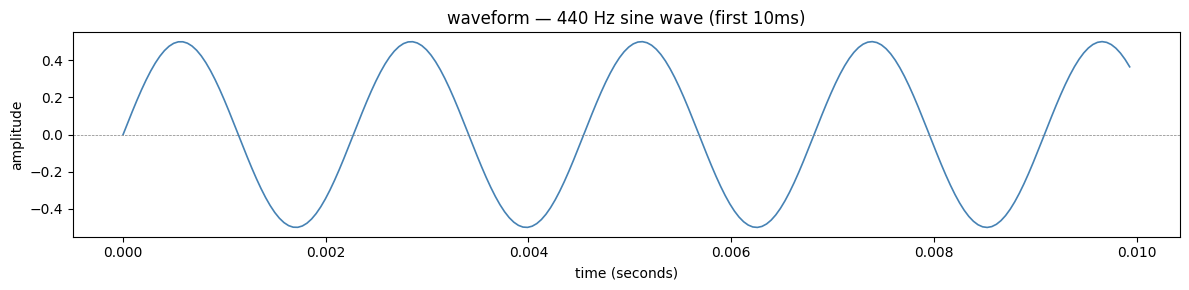

In [10]:
samples_to_show = int(SR * 0.01)   # 0.01 seconds worth of samples

plt.figure(figsize=(12, 3))
plt.plot(t[:samples_to_show], wave[:samples_to_show], color="steelblue", linewidth=1.2)
plt.axhline(0, color="gray", linewidth=0.5, linestyle="--")
plt.title("waveform — 440 Hz sine wave (first 10ms)")
plt.xlabel("time (seconds)")
plt.ylabel("amplitude")
plt.tight_layout()
plt.show()

## frequency affects pitch — comparing two waves

- 880 Hz is exactly twice the frequency of 440 Hz — one octave higher
- same amplitude, same duration — only the frequency changes
- the 880 Hz wave completes **twice as many cycles** in the same time window
- count the peaks in each plot to confirm this

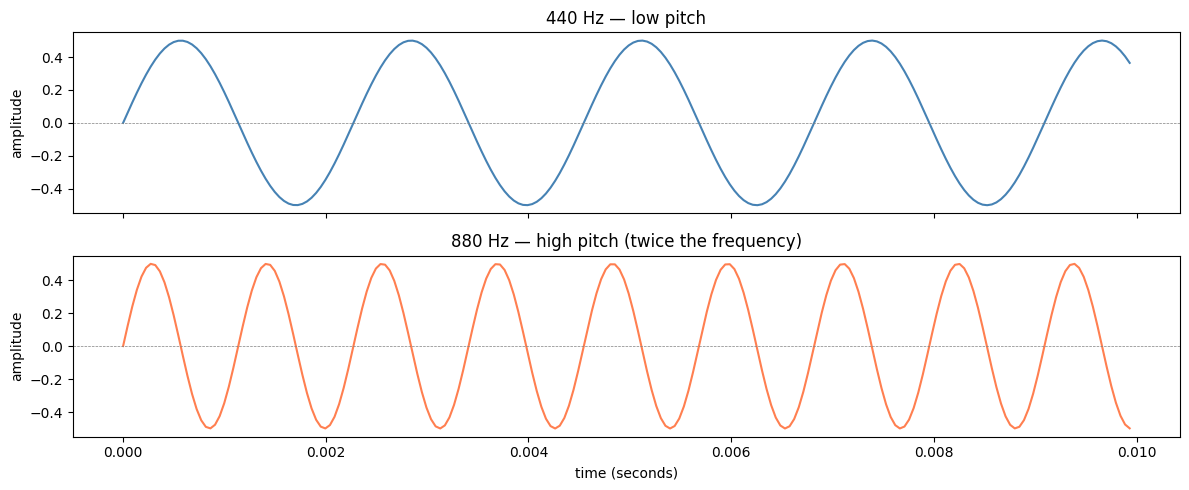

listening to 880 Hz:


In [11]:
wave_low = amplitude * np.sin(2 * np.pi * 440 * t)    # 440 Hz — concert A
wave_high = amplitude * np.sin(2 * np.pi * 880 * t)   # 880 Hz — one octave higher

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

axes[0].plot(t[:samples_to_show], wave_low[:samples_to_show], color="steelblue")
axes[0].set_title("440 Hz — low pitch")
axes[0].set_ylabel("amplitude")
axes[0].axhline(0, color="gray", linewidth=0.5, linestyle="--")

axes[1].plot(t[:samples_to_show], wave_high[:samples_to_show], color="coral")
axes[1].set_title("880 Hz — high pitch (twice the frequency)")
axes[1].set_ylabel("amplitude")
axes[1].set_xlabel("time (seconds)")
axes[1].axhline(0, color="gray", linewidth=0.5, linestyle="--")

plt.tight_layout()
plt.show()

print("listening to 880 Hz:")
ipd.display(ipd.Audio(data=wave_high, rate=SR))

## mixing two frequencies

- real sounds are never a single clean frequency — they are **many frequencies mixed together**
- adding two sine waves simulates this
- the result looks complex and irregular — even though it is just two simple waves summed
- the frequency information is now **buried** in the shape of the wave

This is exactly the problem the **Fourier Transform** solves — given this messy waveform, recover the original components. That is what the next notebook is entirely about.

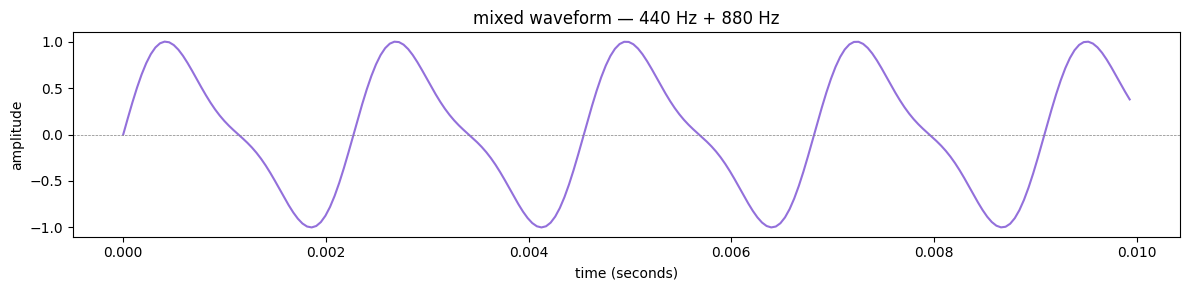

listening to the mix:


In [12]:
wave_mixed = wave_low + 0.3 * wave_high   # 440 Hz dominant, 880 Hz quieter overtone
wave_mixed = wave_mixed / wave_mixed.max() # normalize to [-1, 1]

plt.figure(figsize=(12, 3))
plt.plot(t[:samples_to_show], wave_mixed[:samples_to_show], color="mediumpurple")
plt.axhline(0, color="gray", linewidth=0.5, linestyle="--")
plt.title("mixed waveform — 440 Hz + 880 Hz")
plt.xlabel("time (seconds)")
plt.ylabel("amplitude")
plt.tight_layout()
plt.show()

print("listening to the mix:")
ipd.display(ipd.Audio(data=wave_mixed, rate=SR))

## what we can and cannot see in a waveform

| visible in waveform | hidden in waveform |
|---|---|
| when audio is loud or quiet | which frequencies are present |
| overall duration | pitch of a sound |
| silence vs sound | vowel vs consonant |
| amplitude envelope | timbre and tone quality |